<a href="https://colab.research.google.com/github/dudaoliani/Exerc-cios-Cap-tulo-6/blob/main/Exerc%C3%ADcios_6_1_ao_6_9_l_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup concluído. Pronto para os exercícios.
--- EXERCÍCIO 6.1 & 6.2: LIMITES PRELIMINARES ---


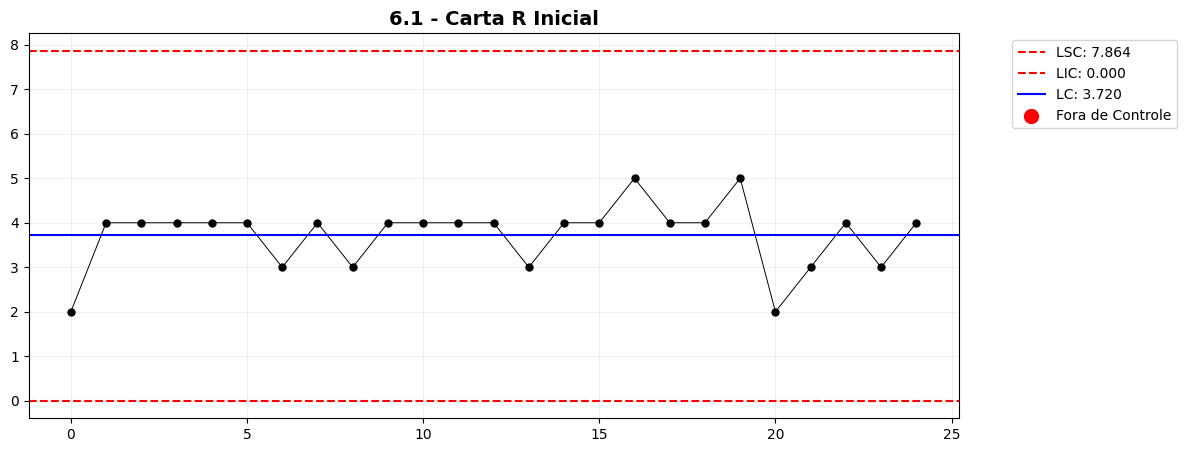

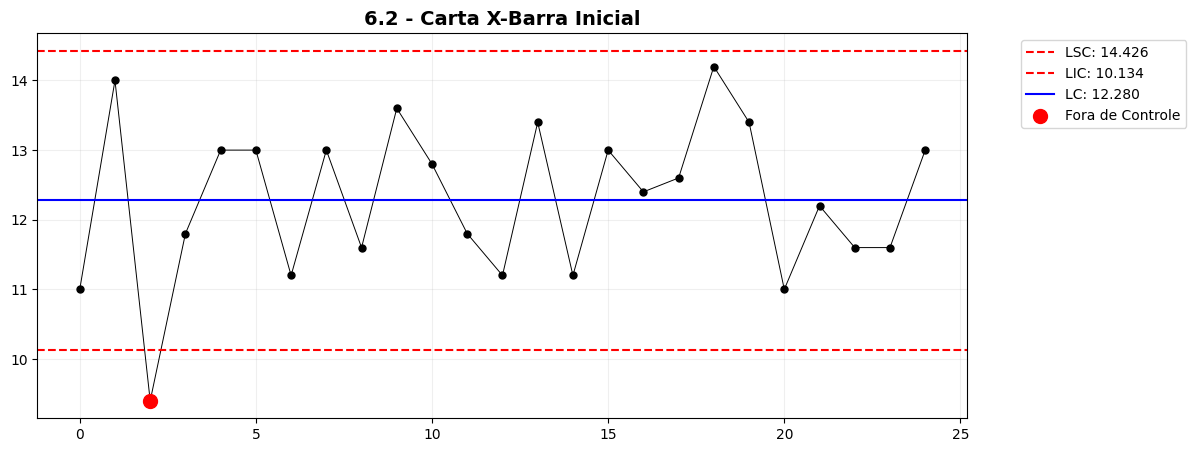

--- EXERCÍCIO 6.3: ANÁLISE DE CAUSAS ESPECIAIS ---
 Nenhuma causa especial encontrada. Limites originais mantidos.

--- RESULTADOS DOS EXERCÍCIOS 6.4 A 6.7 ---
Exercício 6.5 - Sigma Estimado (σ): 1.5993
Exercício 6.4 - Índice Cp: 1.2505
Exercício 6.7 - Índice Cpk: 1.1922
Exercício 6.6 - Fração Não Conforme: 0.000217 (0.0217%)


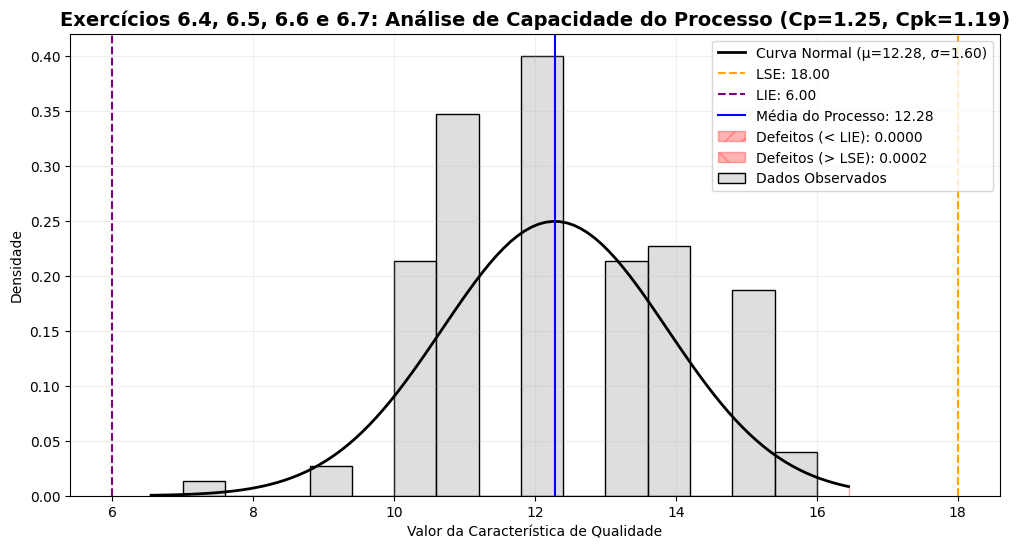

--- EXERCÍCIOS 6.8 & 6.9: INDIVIDUAIS ---


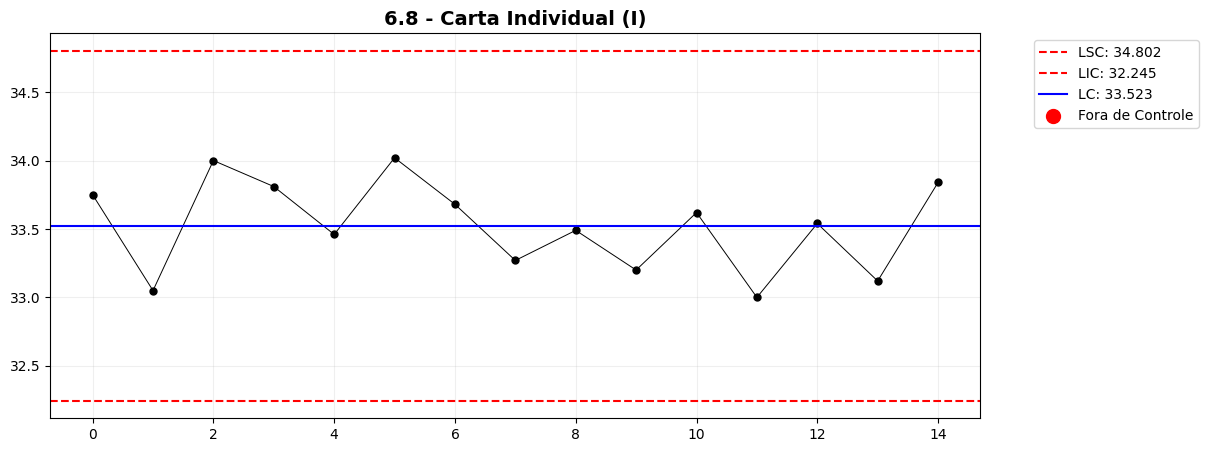

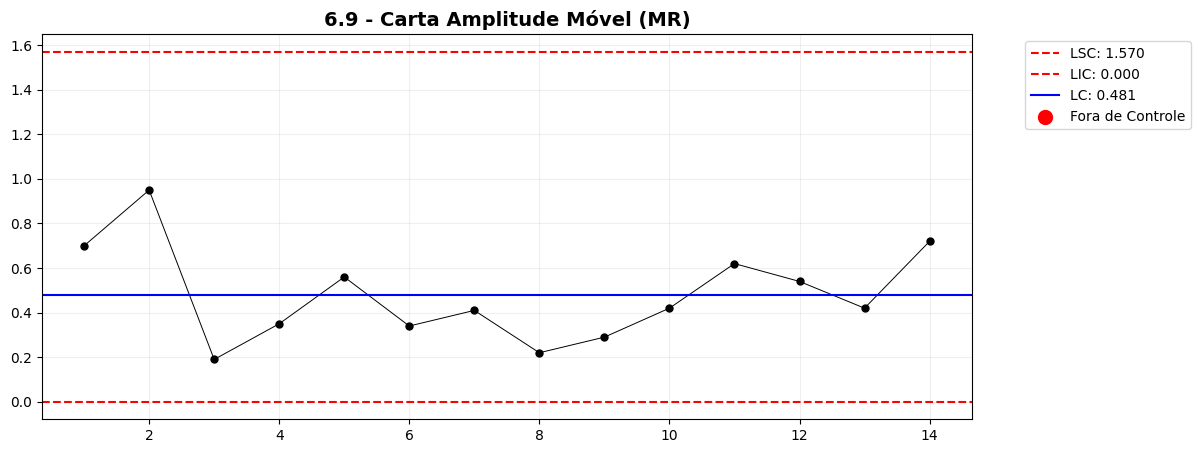

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns # Garantir que o seaborn seja importado para o histplot

# Constantes de Shewhart para limites de controle (Tabela A3)
# n: [d2, D3, D4, A2] -> n é o tamanho do subgrupo
tabela_constantes = {
    2: [1.128, 0, 3.267, 1.880],
    3: [1.693, 0, 2.574, 1.023],
    4: [2.059, 0, 2.282, 0.729],
    5: [2.326, 0, 2.114, 0.577],
    6: [2.534, 0, 2.004, 0.483]
}

def plotar_estilizado(dados, lsc, lic, lc, titulo):
    """Função para gerar o gráfico seguindo o padrão visual do professor"""
    plt.figure(figsize=(12, 5))
    plt.plot(dados, marker='o', color='black', markersize=5, linestyle='-', linewidth=0.7)
    plt.axhline(lsc, color='red', linestyle='--', label=f'LSC: {lsc:.3f}')
    # Plotar LIC apenas se não for zero, ou se o processo puder ter um limite inferior (ex: X-Barra)
    # Para gráficos R, D3 pode ser 0, tornando LIC_R = 0.
    # A implementação atual de plotar_estilizado sempre plota o LIC.
    # Se LIC for 0, axhline estará em 0, o que é aceitável para gráficos R.
    plt.axhline(lic, color='red', linestyle='--', label=f'LIC: {lic:.3f}')
    plt.axhline(lc, color='blue', label=f'LC: {lc:.3f}')

    # Destacar pontos fora de controle
    fora = dados[(dados > lsc) | (dados < lic)]
    plt.scatter(fora.index, fora, color='red', s=100, zorder=5, label='Fora de Controle')

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

print("Setup concluído. Pronto para os exercícios.")


# Dados de exemplo do livro (n=5, 25 amostras)
dados = {
    'S1': [10, 15, 7, 12, 11, 15, 10, 14, 11, 15, 12, 10, 9, 13, 10, 13, 15, 15, 14, 16, 12, 11, 10, 12, 13],
    'S2': [12, 14, 10, 11, 13, 11, 11, 13, 10, 13, 15, 12, 11, 15, 10, 12, 14, 12, 15, 13, 11, 14, 11, 13, 15],
    'S3': [11, 16, 9, 10, 15, 13, 10, 15, 12, 11, 11, 11, 12, 14, 11, 15, 12, 11, 14, 15, 10, 12, 11, 10, 12],
    'S4': [10, 12, 11, 14, 12, 14, 12, 12, 13, 14, 12, 14, 11, 12, 14, 11, 11, 12, 16, 12, 12, 13, 14, 12, 14],
    'S5': [12, 13, 10, 12, 14, 12, 13, 11, 12, 15, 14, 12, 13, 13, 11, 14, 10, 13, 12, 11, 10, 11, 12, 11, 11]
}
df = pd.DataFrame(dados)
n = 5
d2, D3, D4, A2 = tabela_constantes[n]

# Exercício 6.1: Carta R (Amplitude)
df['Media'] = df.mean(axis=1)
df['Amplitude'] = df.iloc[:, :n].max(axis=1) - df.iloc[:, :n].min(axis=1)

r_bar = df['Amplitude'].mean()
LSC_R = D4 * r_bar
LIC_R = D3 * r_bar

# Exercício 6.2: Carta X-Barra
x_double_bar = df['Media'].mean()
LSC_X = x_double_bar + A2 * r_bar
LIC_X = x_double_bar - A2 * r_bar

print("--- EXERCÍCIO 6.1 & 6.2: LIMITES PRELIMINARES ---")
plotar_estilizado(df['Amplitude'], LSC_R, LIC_R, r_bar, "6.1 - Carta R Inicial")
plotar_estilizado(df['Media'], LSC_X, LIC_X, x_double_bar, "6.2 - Carta X-Barra Inicial")


# Identificando amostras com causas especiais (Amplitude > LSC_R)
amostras_fora = df[df['Amplitude'] > LSC_R].index.tolist()

print(f"--- EXERCÍCIO 6.3: ANÁLISE DE CAUSAS ESPECIAIS ---")
if len(amostras_fora) > 0:
    print(f" Amostras removidas por instabilidade na amplitude: {amostras_fora}")
    df_revisado = df.drop(amostras_fora).reset_index(drop=True)

    # Recalculando tudo com os dados "limpos"
    r_bar_rev = df_revisado['Amplitude'].mean()
    x_double_bar_rev = df_revisado['Media'].mean()

    # Novos limites revisados
    LSC_R_rev = D4 * r_bar_rev
    LIC_R_rev = D3 * r_bar_rev # Corrigido: garantir que LIC_R_rev seja calculado aqui
    LSC_X_rev = x_double_bar_rev + A2 * r_bar_rev
    LIC_X_rev = x_double_bar_rev - A2 * r_bar_rev

    print(f"Novo R-barra: {r_bar_rev:.4f}")
    print(f"Novo X-barra-barra: {x_double_bar_rev:.4f}")

    # Plotar gráficos revisados para R e X-Barra
    plotar_estilizado(df_revisado['Amplitude'], LSC_R_rev, LIC_R_rev, r_bar_rev, "6.3 - Carta R Revisada")
    plotar_estilizado(df_revisado['Media'], LSC_X_rev, LIC_X_rev, x_double_bar_rev, "6.3 - Carta X-Barra Revisada")

else:
    print(" Nenhuma causa especial encontrada. Limites originais mantidos.")
    r_bar_rev, x_double_bar_rev = r_bar, x_double_bar
    LSC_R_rev, LIC_R_rev = LSC_R, LIC_R # Corrigido: Garantir que as variáveis _rev sejam definidas a partir das originais se não houver remoção
    LSC_X_rev, LIC_X_rev = LSC_X, LIC_X
    df_revisado = df.copy() # Garantir que df_revisado exista para consistência dos dados do gráfico de capacidade


# Exercício 6.4: Cp (Capacidade Potencial)
cp = (LSE - LIE) / (6 * sigma_est)

# Exercício 6.5: Estimativa do Desvio Padrão Real (Sigma)
sigma_est = r_bar_rev / d2

# Dados de Engenharia (Especificações)
LSE, LIE = 18.0, 6.0

# Exercício 6.6: Fração Não Conforme (Área fora de LIE e LSE na Normal)
# Z = (X - Média) / Sigma
z_sup = (LSE - x_double_bar_rev) / sigma_est
z_inf = (LIE - x_double_bar_rev) / sigma_est
fracao_defeito = (1 - norm.cdf(z_sup)) + norm.cdf(z_inf)

print(f"\n--- RESULTADOS DOS EXERCÍCIOS 6.4 A 6.7 ---")
print(f"Exercício 6.5 - Sigma Estimado (σ): {sigma_est:.4f}")
print(f"Exercício 6.4 - Índice Cp: {cp:.4f}")
print(f"Exercício 6.7 - Índice Cpk: {cpk:.4f}")
print(f"Exercício 6.6 - Fração Não Conforme: {fracao_defeito:.6f} ({fracao_defeito*100:.4f}%)")


# Exercício 6.7: Cpk (Capacidade Real/Centralizada)
cpk = min((LSE - x_double_bar_rev)/(3 * sigma_est), (x_double_bar_rev - LIE)/(3 * sigma_est))


# Gráfico de Capacidade do Processo (visualizando 6.4-6.7)
plt.figure(figsize=(12, 6))

# Obter pontos de dados individuais do dataframe revisado para o histograma
# Usar unstack para obter todos os valores individuais das colunas S1-S5
all_individual_data = df_revisado.iloc[:, :n].unstack().dropna()

# Plotar histograma
sns.histplot(all_individual_data, bins=15, kde=False, stat="density", color="lightgray", label="Dados Observados")

# Plotar distribuição normal estimada
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, x_double_bar_rev, sigma_est)
plt.plot(x, p, 'k', linewidth=2, label=f'Curva Normal (μ={x_double_bar_rev:.2f}, σ={sigma_est:.2f})')

# Adicionar limites de especificação
plt.axvline(LSE, color='orange', linestyle='--', label=f'LSE: {LSE:.2f}')
plt.axvline(LIE, color='purple', linestyle='--', label=f'LIE: {LIE:.2f}')
plt.axvline(x_double_bar_rev, color='blue', linestyle='-', label=f'Média do Processo: {x_double_bar_rev:.2f}')

# Sombrear áreas não conformes
# Para a cauda inferior
x_inf_shade = np.linspace(xmin, LIE, 50)
if len(x_inf_shade) > 1: # Garantir que haja pontos para plotar
    # Sombrear apenas se LIE estiver dentro dos limites do plot
    if LIE > xmin:
        plt.fill_between(x_inf_shade, 0, norm.pdf(x_inf_shade, x_double_bar_rev, sigma_est), color='red', alpha=0.3, hatch='//', label=f'Defeitos (< LIE): {norm.cdf(LIE, x_double_bar_rev, sigma_est):.4f}')
    else: # Se LIE estiver fora de xmin, sombrear de xmin para xmin
        plt.fill_between(np.linspace(xmin, xmin, 2), 0, norm.pdf(np.linspace(xmin, xmin, 2), x_double_bar_rev, sigma_est), color='red', alpha=0.3, hatch='//', label=f'Defeitos (< LIE): {norm.cdf(LIE, x_double_bar_rev, sigma_est):.4f}')
# Para a cauda superior
x_sup_shade = np.linspace(LSE, xmax, 50)
if len(x_sup_shade) > 1: # Garantir que haja pontos para plotar
    # Sombrear apenas se LSE estiver dentro dos limites do plot
    if LSE < xmax:
        plt.fill_between(x_sup_shade, 0, norm.pdf(x_sup_shade, x_double_bar_rev, sigma_est), color='red', alpha=0.3, hatch='\\', label=f'Defeitos (> LSE): {1 - norm.cdf(LSE, x_double_bar_rev, sigma_est):.4f}')
    else: # Se LSE estiver fora de xmax, sombrear de xmax para xmax
        plt.fill_between(np.linspace(xmax, xmax, 2), 0, norm.pdf(np.linspace(xmax, xmax, 2), x_double_bar_rev, sigma_est), color='red', alpha=0.3, hatch='\\', label=f'Defeitos (> LSE): {1 - norm.cdf(LSE, x_double_bar_rev, sigma_est):.4f}')


plt.title(f"Exercícios 6.4, 6.5, 6.6 e 6.7: Análise de Capacidade do Processo (Cp={cp:.2f}, Cpk={cpk:.2f})", fontsize=14, fontweight='bold')
plt.xlabel("Valor da Característica de Qualidade")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Dados de viscosidade (Exemplo 6.8)
viscosidade = [33.75, 33.05, 34.00, 33.81, 33.46, 34.02, 33.68, 33.27, 33.49, 33.20, 33.62, 33.00, 33.54, 33.12, 33.84]
df_i = pd.DataFrame(viscosidade, columns=['X'])

# Exercício 6.9: Amplitude Móvel (Moving Range)
# Subtrai o valor atual do anterior e tira o valor absoluto
df_i['MR'] = df_i['X'].diff().abs()

x_bar_i = df_i['X'].mean()
mr_bar_i = df_i['MR'].mean()

# Para I-MR, as constantes d2 e D4 são baseadas em n=2 (comparação entre dois pontos)
d2_i, D3_i, D4_i, A2_i = tabela_constantes[2]

# Exercício 6.8: Limites para Individuais
LSC_I = x_bar_i + 3 * (mr_bar_i / d2_i)
LIC_I = x_bar_i - 3 * (mr_bar_i / d2_i)
LSC_MR = D4_i * mr_bar_i

print("--- EXERCÍCIOS 6.8 & 6.9: INDIVIDUAIS ---")
plotar_estilizado(df_i['X'], LSC_I, LIC_I, x_bar_i, "6.8 - Carta Individual (I)")
plotar_estilizado(df_i['MR'].dropna(), LSC_MR, 0, mr_bar_i, "6.9 - Carta Amplitude Móvel (MR)")

### Tabela Resumo dos Resultados

In [11]:
resultados_sumario = {
    'Métrica': [
        'R-Barra (Inicial)',
        'X-Barra (Inicial)',
        'R-Barra (Revisado/Final)',
        'X-Barra (Revisado/Final)',
        'Sigma Estimado (σ)',
        'Índice Cp',
        'Índice Cpk',
        'Fração Não Conforme',
        'Média Individual (I)',
        'Amplitude Móvel Média (MR)'
    ],
    'Exercício': [
        '6.1',
        '6.2',
        '6.3',
        '6.3',
        '6.5',
        '6.4',
        '6.7',
        '6.6',
        '6.8',
        '6.9'
    ],
    'Valor': [
        f'{r_bar:.4f}',
        f'{x_double_bar:.4f}',
        f'{r_bar_rev:.4f}',
        f'{x_double_bar_rev:.4f}',
        f'{sigma_est:.4f}',
        f'{cp:.4f}',
        f'{cpk:.4f}',
        f'{fracao_defeito*100:.4f}% ({fracao_defeito:.6f})',
        f'{x_bar_i:.4f}',
        f'{mr_bar_i:.4f}'
    ]
}

df_sumario = pd.DataFrame(resultados_sumario)
display(df_sumario)

,Métrica,Exercício,Valor
0,R-Barra (Inicial),6.1,3.7200
1,X-Barra (Inicial),6.2,12.2800
2,R-Barra (Revisado/Final),6.3,3.7200
3,X-Barra (Revisado/Final),6.3,12.2800
4,Sigma Estimado (σ),6.5,1.5993
5,Índice Cp,6.4,1.2505
6,Índice Cpk,6.7,1.1922
7,Fração Não Conforme,6.6,0.0217% (0.000217)
8,Média Individual (I),6.8,33.5233
9,Amplitude Móvel Média (MR),6.9,0.4807
